# Generalized Cauchy Kernel: Exact vs RFF Approximation

This notebook demonstrates the Random Fourier Feature (RFF) approximation for the Generalized Cauchy kernel.

## Kernel Definition

The Generalized Cauchy kernel is defined as:
$$k(x, x') = \left(1 + \frac{\|x - x'\|^\alpha}{2\beta}\right)^{-\beta}$$

where $\alpha \in (0, 2]$ and $\beta > 0$.

In [1]:
using Pkg
Pkg.activate("..")

  Activating project at `~/GeneralizedRFF.jl`


In [2]:
using GeneralizedRFF
using KernelFunctions
using KernelFunctions: ColVecs
using AbstractGPs
using Random
using LinearAlgebra
using Plots
gr()

Random.seed!(42)

TaskLocalRNG()

## 1. Kernel Matrix Comparison (Heatmap)

In [3]:
# Define kernel parameters
alpha = 1.5
beta = 2.0
k = GeneralizedCauchyKernel(alpha, beta)

println("Kernel: ", k)

Kernel: Generalized Cauchy Kernel (α = 1.5, β = 2.0, metric = Distances.Euclidean(0.0))


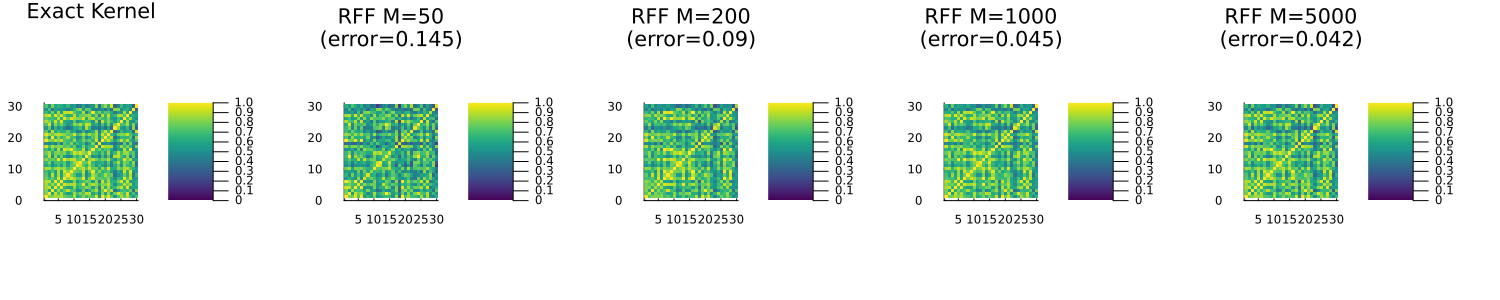

In [4]:
# Generate test data
n = 30
X = [rand(2) * 2 for _ in 1:n]

# Exact kernel matrix
K_exact = kernelmatrix(k, X)

# RFF approximation with different M values
M_values = [50, 200, 1000, 5000]
rng = MersenneTwister(123)

plots = [heatmap(K_exact, title="Exact Kernel", c=:viridis, aspect_ratio=1, clim=(0, 1))]

for M in M_values
    K_approx = rff_kernelmatrix(MersenneTwister(123), k, X, M)
    rel_error = norm(K_exact - K_approx) / norm(K_exact)
    push!(plots, heatmap(K_approx, title="RFF M=$M\n(error=$(round(rel_error, digits=3)))", 
                         c=:viridis, aspect_ratio=1, clim=(0, 1)))
end

plot(plots..., layout=(1, 5), size=(1500, 300))

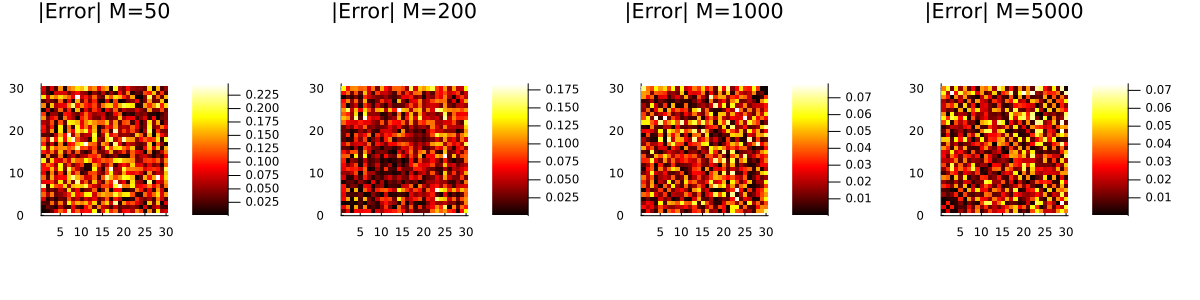

In [5]:
# Error difference heatmaps
error_plots = []
for M in M_values
    K_approx = rff_kernelmatrix(MersenneTwister(123), k, X, M)
    K_diff = abs.(K_exact - K_approx)
    push!(error_plots, heatmap(K_diff, title="|Error| M=$M", c=:hot, aspect_ratio=1))
end

plot(error_plots..., layout=(1, 4), size=(1200, 300))

## 2. Convergence Analysis

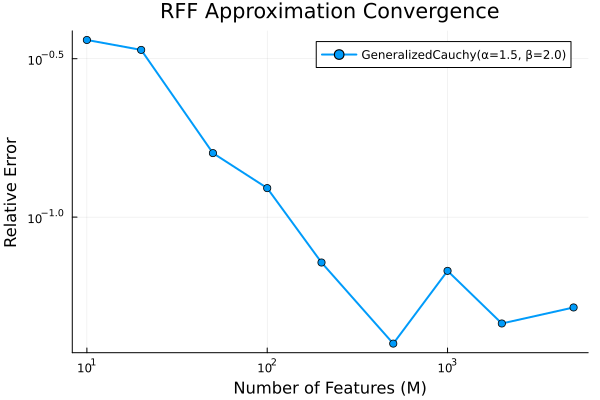

In [6]:
# Analyze convergence with M
M_range = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
errors = Float64[]

for M in M_range
    K_approx = rff_kernelmatrix(MersenneTwister(42), k, X, M)
    rel_error = norm(K_exact - K_approx) / norm(K_exact)
    push!(errors, rel_error)
end

plot(M_range, errors, marker=:circle, xlabel="Number of Features (M)", 
     ylabel="Relative Error", label="GeneralizedCauchy(α=$alpha, β=$beta)",
     xscale=:log10, yscale=:log10, legend=:topright,
     title="RFF Approximation Convergence", linewidth=2)

## 3. 1D Gaussian Process Comparison

In [7]:
# Generate 1D data
n_train = 10
x_train = sort(rand(n_train) * 4 .- 2)
y_train = sin.(2 * x_train) .+ 0.2 * randn(n_train)

x_test = range(-2.5, 2.5, length=200)

# Wrap data for AbstractGPs
X_train = [[x] for x in x_train]
X_test = [[x] for x in x_test]

200-element Vector{Vector{Float64}}:
 [-2.5]
 [-2.4748743718592965]
 [-2.449748743718593]
 [-2.4246231155778895]
 [-2.399497487437186]
 [-2.3743718592964824]
 [-2.349246231155779]
 [-2.3241206030150754]
 [-2.298994974874372]
 [-2.2738693467336684]
 [-2.248743718592965]
 [-2.2236180904522613]
 [-2.198492462311558]
 ⋮
 [2.2236180904522613]
 [2.248743718592965]
 [2.2738693467336684]
 [2.298994974874372]
 [2.3241206030150754]
 [2.349246231155779]
 [2.3743718592964824]
 [2.399497487437186]
 [2.4246231155778895]
 [2.449748743718593]
 [2.4748743718592965]
 [2.5]

In [8]:
# Exact GP
k_1d = GeneralizedCauchyKernel(1.5, 2.0)
f_exact = GP(k_1d)
fx_exact = f_exact(X_train, 0.1)
p_exact = posterior(fx_exact, y_train)

# Predictions
m_exact = mean(p_exact(X_test))
s_exact = sqrt.(var(p_exact(X_test)))

200-element Vector{Float64}:
 0.9243460137695341
 0.9218134029439544
 0.9191904230635612
 0.9164738009530724
 0.913660151868847
 0.9107459765648116
 0.907727658364747
 0.9046014602504648
 0.9013635219764146
 0.8980098572223318
 0.8945363507967052
 0.8909387559050896
 0.8872126914986316
 ⋮
 0.4922283816623302
 0.5085371502334065
 0.5243853061847406
 0.5397794944443088
 0.5547270991700872
 0.5692360533119509
 0.5833146980734844
 0.59697167711761
 0.6102158553300583
 0.62305625520349
 0.63550200606045
 0.647562302782267

In [9]:
# RFF approximation for GP
function rff_gp_predict(k, X_train, y_train, X_test, M; noise=0.1)
    rng = MersenneTwister(42)
    d = length(first(X_train))
    basis = sample_generalized_rff_basis(rng, k, d, M)
    
    # Compute features
    Phi_train_mat = hcat(X_train...)
    Phi_test_mat = hcat(X_test...)
    
    features_train = basis(ColVecs(Phi_train_mat))
    features_test = basis(ColVecs(Phi_test_mat))
    
    Phi_train = hcat([features_train[i] for i in 1:length(X_train)]...)'
    Phi_test = hcat([features_test[i] for i in 1:length(X_test)]...)'
    
    # Bayesian linear regression with RFF features
    n, m = size(Phi_train)
    A = Phi_train' * Phi_train + noise^2 * I(m)
    w_mean = A \ (Phi_train' * y_train)
    
    # Predictive mean and variance
    m_pred = Phi_test * w_mean
    Sigma_w = noise^2 * inv(A)
    v_pred = [Phi_test[i, :]' * Sigma_w * Phi_test[i, :] + noise^2 for i in 1:size(Phi_test, 1)]
    
    return m_pred, sqrt.(v_pred)
end

rff_gp_predict (generic function with 1 method)

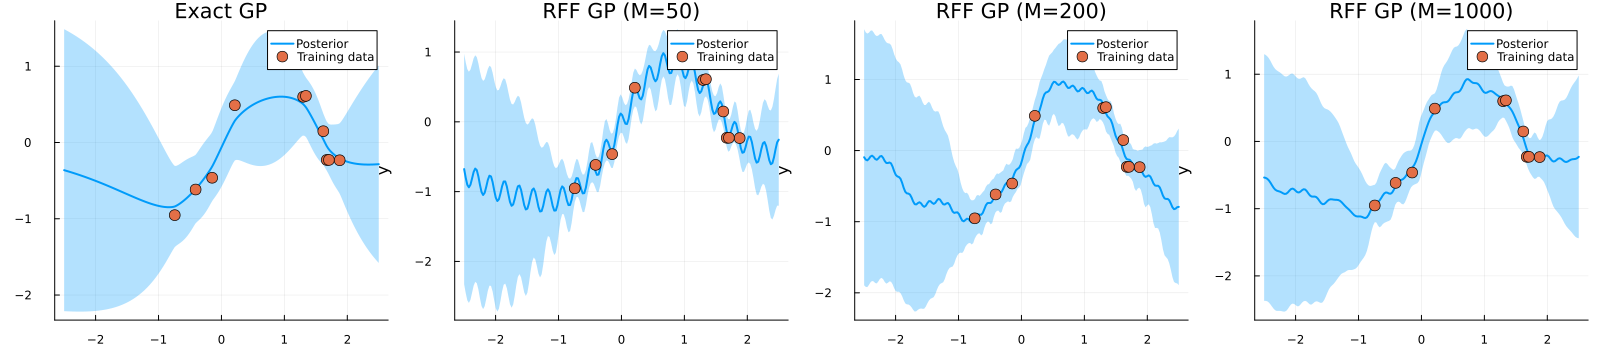

In [10]:
# Compare GP predictions
p1 = plot(title="Exact GP", xlabel="x", ylabel="y", legend=:topright)
plot!(p1, x_test, m_exact, ribbon=2*s_exact, fillalpha=0.3, label="Posterior", linewidth=2)
scatter!(p1, x_train, y_train, label="Training data", markersize=6)

M_vals = [50, 200, 1000]
rff_plots = []
for M in M_vals
    m_rff, s_rff = rff_gp_predict(k_1d, X_train, y_train, X_test, M)
    p = plot(title="RFF GP (M=$M)", xlabel="x", ylabel="y", legend=:topright)
    plot!(p, x_test, m_rff, ribbon=2*s_rff, fillalpha=0.3, label="Posterior", linewidth=2)
    scatter!(p, x_train, y_train, label="Training data", markersize=6)
    push!(rff_plots, p)
end

plot(p1, rff_plots..., layout=(1, 4), size=(1600, 350))

## 4. 2D Gaussian Process Comparison

In [11]:
# Generate 2D data
n_train_2d = 30
X_train_2d = [rand(2) * 4 .- 2 for _ in 1:n_train_2d]
y_train_2d = [sin(x[1]) * cos(x[2]) + 0.1 * randn() for x in X_train_2d]

# Test grid
x1_range = range(-2.5, 2.5, length=40)
x2_range = range(-2.5, 2.5, length=40)
X_test_2d = [[x1, x2] for x1 in x1_range for x2 in x2_range]

1600-element Vector{Vector{Float64}}:
 [-2.5, -2.5]
 [-2.5, -2.371794871794872]
 [-2.5, -2.2435897435897436]
 [-2.5, -2.1153846153846154]
 [-2.5, -1.9871794871794872]
 [-2.5, -1.858974358974359]
 [-2.5, -1.7307692307692308]
 [-2.5, -1.6025641025641026]
 [-2.5, -1.4743589743589745]
 [-2.5, -1.3461538461538463]
 [-2.5, -1.2179487179487178]
 [-2.5, -1.0897435897435896]
 [-2.5, -0.9615384615384616]
 ⋮
 [2.5, 1.0897435897435896]
 [2.5, 1.2179487179487178]
 [2.5, 1.3461538461538463]
 [2.5, 1.4743589743589745]
 [2.5, 1.6025641025641026]
 [2.5, 1.7307692307692308]
 [2.5, 1.858974358974359]
 [2.5, 1.9871794871794872]
 [2.5, 2.1153846153846154]
 [2.5, 2.2435897435897436]
 [2.5, 2.371794871794872]
 [2.5, 2.5]

In [12]:
# Exact GP for 2D
k_2d = GeneralizedCauchyKernel(1.5, 2.0)
f_exact_2d = GP(k_2d)
fx_exact_2d = f_exact_2d(X_train_2d, 0.1)
p_exact_2d = posterior(fx_exact_2d, y_train_2d)

m_exact_2d = mean(p_exact_2d(X_test_2d))
m_exact_grid = reshape(m_exact_2d, length(x1_range), length(x2_range))

40×40 Matrix{Float64}:
 -0.0773359  -0.0709396  -0.0636246  -0.0555419  …  -0.118155   -0.0958384
 -0.0904411  -0.0837964  -0.0760436  -0.067359      -0.108166   -0.083574
 -0.106193   -0.0994546  -0.0913742  -0.0821484     -0.0905537  -0.0643431
 -0.125045   -0.118452   -0.110229   -0.100578      -0.0634191  -0.0368309
 -0.147479   -0.141383   -0.133316   -0.123452      -0.0252016  -0.000131504
 -0.173964   -0.168869   -0.161423   -0.151722   …   0.0246769   0.0458598
 -0.204902   -0.20149    -0.195354   -0.18645        0.0852414   0.100134
 -0.240544   -0.239679   -0.235793   -0.228668       0.153852    0.1605
 -0.280891   -0.28358    -0.283101   -0.279077       0.226538    0.223782
 -0.325613   -0.332919   -0.337094   -0.337641       0.298449    0.286227
 -0.373996   -0.386927   -0.396932   -0.403387   …   0.364469    0.344141
 -0.424939   -0.444355   -0.46117    -0.474566       0.420648    0.394798
 -0.476986   -0.503533   -0.527898   -0.548976       0.466064    0.437215
  ⋮       

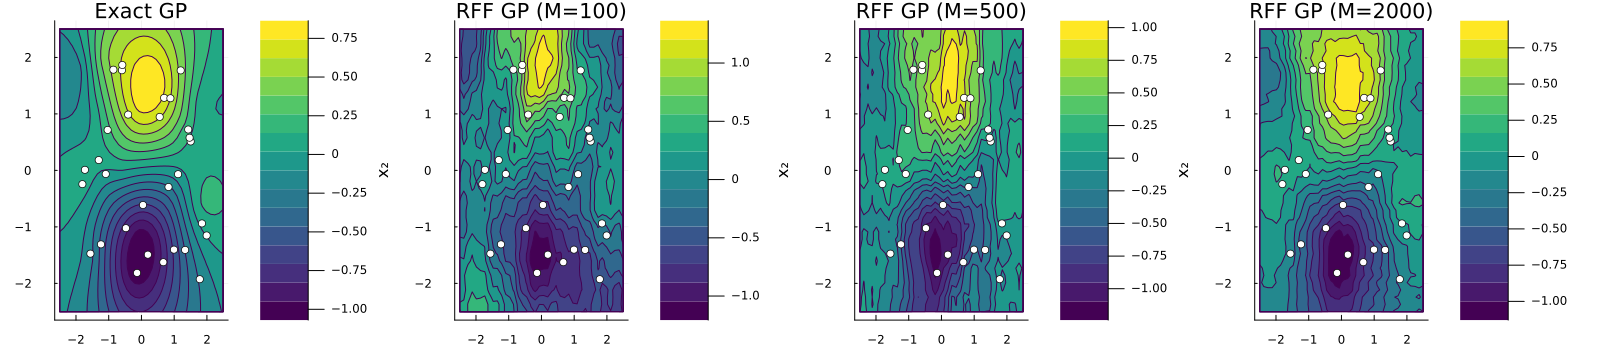

In [13]:
# Plot 2D comparison
p_exact_plot = contourf(x1_range, x2_range, m_exact_grid', 
                        title="Exact GP", xlabel="x₁", ylabel="x₂", c=:viridis)
scatter!(p_exact_plot, [x[1] for x in X_train_2d], [x[2] for x in X_train_2d], 
         c=:white, markersize=4, label="")

rff_2d_plots = [p_exact_plot]
for M in [100, 500, 2000]
    m_rff_2d, _ = rff_gp_predict(k_2d, X_train_2d, y_train_2d, X_test_2d, M)
    m_rff_grid = reshape(m_rff_2d, length(x1_range), length(x2_range))
    
    p_rff = contourf(x1_range, x2_range, m_rff_grid', 
                     title="RFF GP (M=$M)", xlabel="x₁", ylabel="x₂", c=:viridis)
    scatter!(p_rff, [x[1] for x in X_train_2d], [x[2] for x in X_train_2d], 
             c=:white, markersize=4, label="")
    push!(rff_2d_plots, p_rff)
end

plot(rff_2d_plots..., layout=(1, 4), size=(1600, 350))

## 5. Parameter Sensitivity

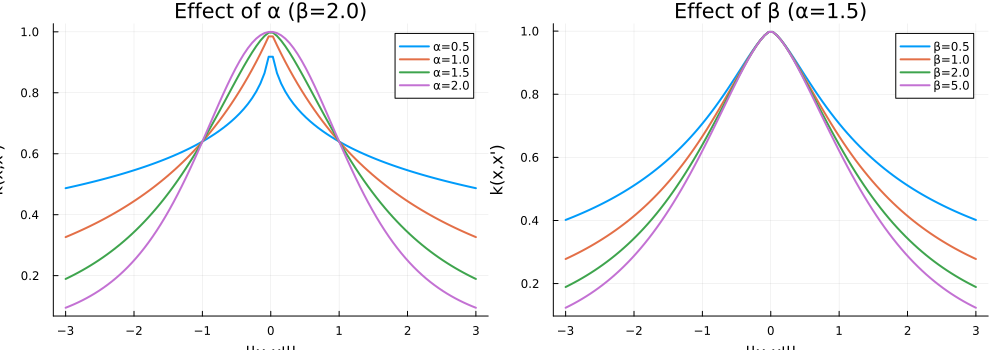

In [14]:
# Compare different kernel parameters
alpha_values = [0.5, 1.0, 1.5, 2.0]
beta_values = [0.5, 1.0, 2.0, 5.0]

x_1d = range(-3, 3, length=100)

# Vary alpha
p_alpha = plot(title="Effect of α (β=2.0)", xlabel="||x-x'||", ylabel="k(x,x')")
for α in alpha_values
    k_α = GeneralizedCauchyKernel(α, 2.0)
    y_k = [k_α([0.0], [x]) for x in x_1d]
    plot!(p_alpha, x_1d, y_k, label="α=$α", linewidth=2)
end

# Vary beta
p_beta = plot(title="Effect of β (α=1.5)", xlabel="||x-x'||", ylabel="k(x,x')")
for β in beta_values
    k_β = GeneralizedCauchyKernel(1.5, β)
    y_k = [k_β([0.0], [x]) for x in x_1d]
    plot!(p_beta, x_1d, y_k, label="β=$β", linewidth=2)
end

plot(p_alpha, p_beta, layout=(1, 2), size=(1000, 350))

## Summary

The Generalized Cauchy kernel RFF approximation:
- Converges to the exact kernel as M increases
- Provides good GP approximations for both 1D and 2D regression
- The approximation quality depends on the kernel parameters α and β